Importy, wczytywanie


In [58]:
import torch
import torch.nn as nn
import csv
import numpy as np
import matplotlib.pyplot as plt

def wczytaj_csv(sciezka):
    x_lista, y_lista = [], []
    with open(sciezka) as f:
        reader = csv.reader(f)
        for i, row in enumerate(reader):
            if i == 0:
                continue
            _, x, y = row
            x_lista.append(float(x))
            y_lista.append(float(y))
    # reshape(-1, 1) lista -> macierz
    return np.array(x_lista).reshape(-1, 1), np.array(y_lista).reshape(-1, 1)

Budowa MLP


In [59]:
def zbuduj_model(architektura):
    warstwy = []
    for i in range(len(architektura) - 1):
        warstwy.append(nn.Linear(architektura[i], architektura[i+1]))

        if i < len(architektura) - 2:
            warstwy.append(nn.Sigmoid())

    return nn.Sequential(*warstwy)

Trenuj

In [60]:
def trenuj(model, x_norm, y_norm, kroki=15000, lr=0.01):
    kryterium = nn.MSELoss()
    optymalizator = torch.optim.Adam(model.parameters(), lr=lr)

    x_t = torch.tensor(x_norm, dtype=torch.float32)
    y_t = torch.tensor(y_norm, dtype=torch.float32)

    historia_strat = []
    for krok in range(1, kroki + 1):
        y_pred = model(x_t)
        strata = kryterium(y_pred, y_t)

        optymalizator.zero_grad()
        strata.backward()
        optymalizator.step()

        historia_strat.append(strata.item())
        if krok % 5000 == 0 or krok == kroki:
            print(f"Krok {krok:5d}/{kroki} | strata (znorm. MSE): {strata.item():.6f}")

    return historia_strat

Kontent

Eksport wag

In [61]:
def eksportuj_wagi(model, nazwa_zmiennej_prefix="wagi"):
    print(f"W_{nazwa_zmiennej_prefix} = []")
    print(f"b_{nazwa_zmiennej_prefix} = []")

    for modul in model:
        if isinstance(modul, nn.Linear):
            W = modul.weight.data.cpu().numpy().T
            b = modul.bias.data.cpu().numpy()

            print(f"W_{nazwa_zmiennej_prefix}.append(np.array({W.tolist()}))")
            print(f"b_{nazwa_zmiennej_prefix}.append(np.array({b.tolist()}))")
    print()

kontent

In [62]:
def uruchom(zbior, architektura, kroki=15000, lr=0.01):
    print(f"Zbiór: {zbior}, Architektura: {architektura}")

    x_train, y_train = wczytaj_csv(f"{zbior}-training.csv")
    x_test,  y_test  = wczytaj_csv(f"{zbior}-test.csv")

    x_min, x_max = x_train.min(), x_train.max()
    y_min, y_max = y_train.min(), y_train.max()

    x_train_n = (x_train - x_min) / (x_max - x_min)
    y_train_n = (y_train - y_min) / (y_max - y_min)
    x_test_n  = (x_test - x_min) / (x_max - x_min)

    model = zbuduj_model(architektura)
    historia = trenuj(model, x_train_n, y_train_n, kroki=kroki, lr=lr)

    with torch.no_grad():
        y_pred_n = model(torch.tensor(x_test_n, dtype=torch.float32)).numpy()

    y_pred = y_pred_n * (y_max - y_min) + y_min

    mse_test = np.mean((y_test - y_pred) ** 2)
    print(f"MSE testowe: {mse_test:.4f}\n")

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.plot(historia)
    plt.title(f"Błąd uczenia - {zbior}")
    plt.yscale("log")

    idx = np.argsort(x_test.flatten())
    plt.subplot(1, 2, 2)
    plt.scatter(x_test, y_test, s=10)
    plt.plot(x_test[idx], y_pred[idx], color="red")
    plt.title("Predykcja")
    plt.show()

    prefix = f"{zbior.replace('-', '_')}_{architektura[1]}"
    eksportuj_wagi(model, prefix)

    return model

Rozwiązania na obu zbiorach

ZBIÓR SQUARE-SIMPLE
Zbiór: square-simple, Architektura: [1, 5, 1]
Krok  5000/15000 | strata (znorm. MSE): 0.000011
Krok 10000/15000 | strata (znorm. MSE): 0.000004
Krok 15000/15000 | strata (znorm. MSE): 0.000002
MSE testowe: 0.2281



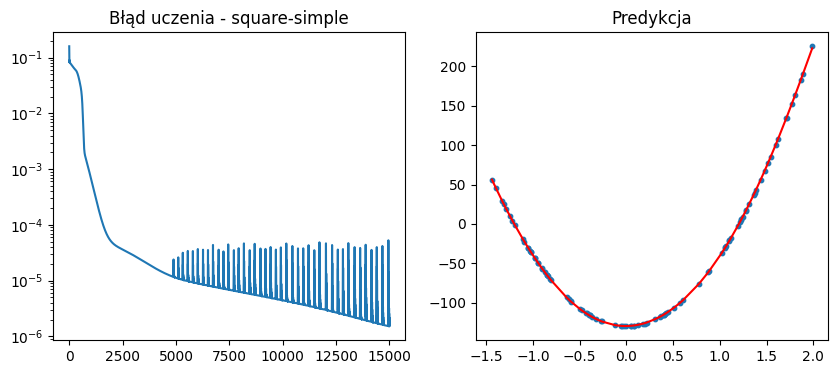

W_square_simple_5 = []
b_square_simple_5 = []
W_square_simple_5.append(np.array([[4.953242778778076, 1.4250167608261108, -6.093924522399902, 10.14172077178955, 1.5980356931686401]]))
b_square_simple_5.append(np.array([-5.2442450523376465, -1.507643699645996, 0.6275937557220459, 1.3560529947280884, -0.8030814528465271]))
W_square_simple_5.append(np.array([[2.5452775955200195], [0.7119996547698975], [1.1575877666473389], [-0.8153394460678101], [0.07405292242765427]]))
b_square_simple_5.append(np.array([0.32505470514297485]))

Zbiór: square-simple, Architektura: [1, 10, 1]
Krok  5000/15000 | strata (znorm. MSE): 0.000016
Krok 10000/15000 | strata (znorm. MSE): 0.000005
Krok 15000/15000 | strata (znorm. MSE): 0.000003
MSE testowe: 0.8845



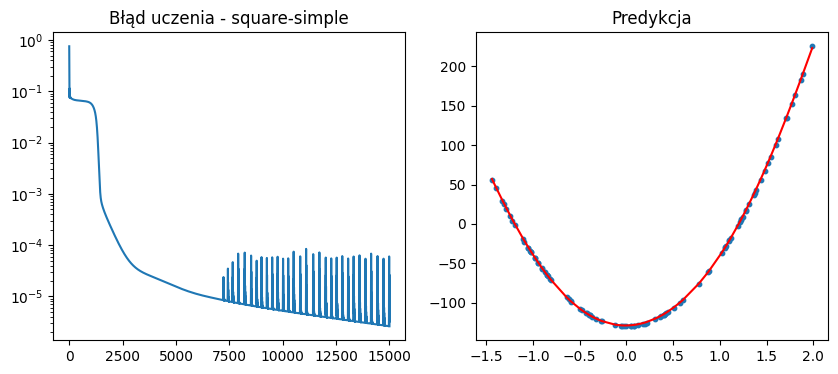

W_square_simple_10 = []
b_square_simple_10 = []
W_square_simple_10.append(np.array([[-0.48849281668663025, -5.63339376449585, -1.5836052894592285, 0.10109694302082062, -5.011031627655029, -0.6648649573326111, -0.49603813886642456, -6.488232135772705, -1.761401891708374, 5.026933193206787]]))
b_square_simple_10.append(np.array([-0.6435440182685852, 0.4239247143268585, 0.8510257005691528, -0.054979629814624786, -0.882515549659729, -0.8230094909667969, -0.6554048657417297, -1.1213051080703735, 1.0146491527557373, -5.279709339141846]))
W_square_simple_10.append(np.array([[-0.05002082511782646], [0.9170043468475342], [-0.25720593333244324], [0.43322744965553284], [0.847606897354126], [-0.026781389489769936], [-0.11596353352069855], [0.649309515953064], [-0.3410928249359131], [2.5115466117858887]]))
b_square_simple_10.append(np.array([-0.09210651367902756]))

Zbiór: square-simple, Architektura: [1, 5, 5, 1]
Krok  5000/20000 | strata (znorm. MSE): 0.000010
Krok 10000/20000 | strata (znorm. MS

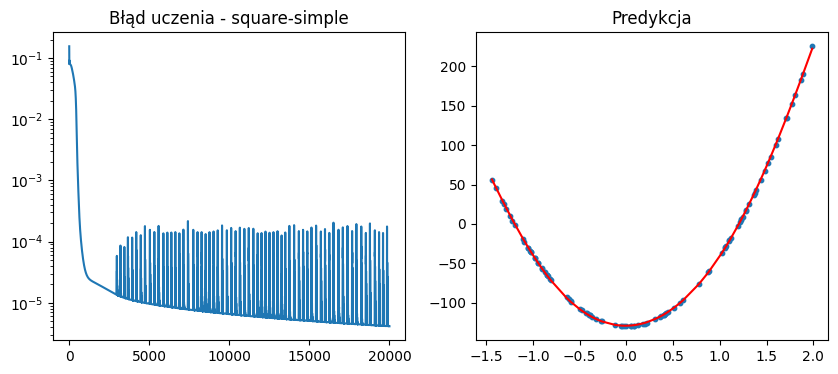

W_square_simple_5 = []
b_square_simple_5 = []
W_square_simple_5.append(np.array([[-0.36699390411376953, 4.119621753692627, 4.704723834991455, -4.16959285736084, 5.5332489013671875]]))
b_square_simple_5.append(np.array([-1.1354297399520874, -5.326563358306885, -4.299782752990723, 5.103175163269043, -0.04593167081475258]))
W_square_simple_5.append(np.array([[0.21307268738746643, -0.1712275743484497, 0.4497597813606262, -0.13227571547031403, 0.36226531863212585], [1.4556300640106201, -1.5282584428787231, 1.1071420907974243, -1.9217180013656616, 1.1867200136184692], [1.382591962814331, -1.3115538358688354, 1.564704179763794, -1.0029008388519287, 1.250431776046753], [-0.2177850902080536, 0.33814528584480286, 0.24568305909633636, 1.1057218313217163, -0.2907562255859375], [-1.7293812036514282, 1.4045385122299194, -1.918552279472351, 0.6604307293891907, -1.5803558826446533]]))
b_square_simple_5.append(np.array([0.644935667514801, -0.44953954219818115, 0.32265594601631165, 0.09956102073192596, 

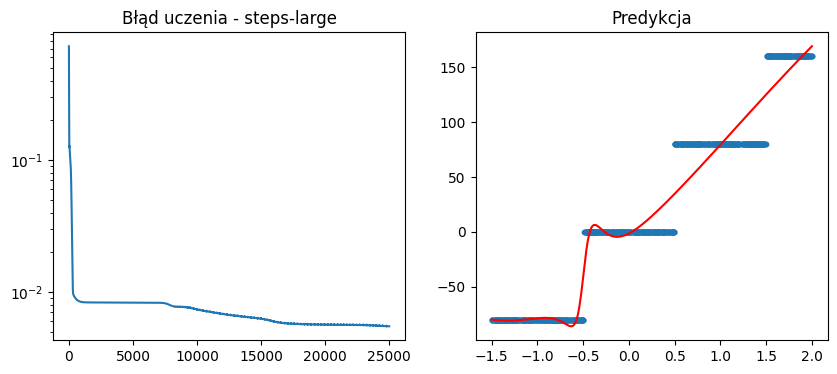

W_steps_large_5 = []
b_steps_large_5 = []
W_steps_large_5.append(np.array([[2.441347360610962, 24.4483642578125, -1.737056851387024, 7.996728897094727, -90.70540618896484]]))
b_steps_large_5.append(np.array([-1.8263442516326904, -7.26613712310791, 2.0110538005828857, 0.6973912715911865, 25.97185516357422]))
W_steps_large_5.append(np.array([[2.148202896118164], [-0.5144823789596558], [-0.08417920023202896], [-0.44848188757896423], [-0.5768886208534241]]))
b_steps_large_5.append(np.array([0.6540482044219971]))

Zbiór: steps-large, Architektura: [1, 10, 1]
Krok  5000/25000 | strata (znorm. MSE): 0.008280
Krok 10000/25000 | strata (znorm. MSE): 0.007308
Krok 15000/25000 | strata (znorm. MSE): 0.005881
Krok 20000/25000 | strata (znorm. MSE): 0.004489
Krok 25000/25000 | strata (znorm. MSE): 0.002908
MSE testowe: 162.6072



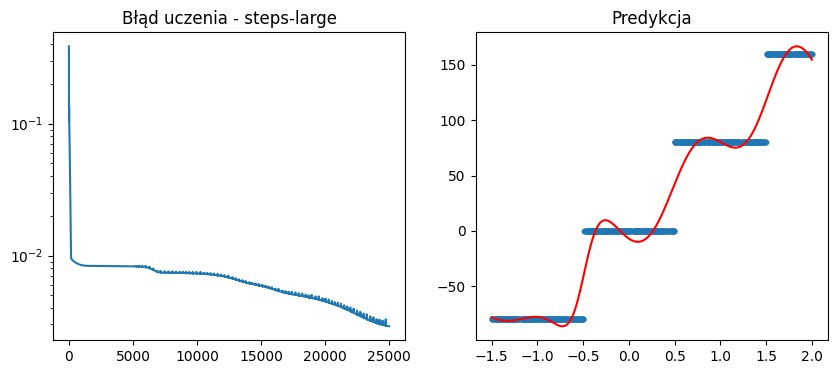

W_steps_large_10 = []
b_steps_large_10 = []
W_steps_large_10.append(np.array([[-17.2454891204834, -17.866151809692383, 2.0917084217071533, 1.8967851400375366, -2.7958850860595703, -3.870823383331299, -9.746570587158203, 14.425165176391602, -2.9155654907226562, 35.286338806152344]]))
b_steps_large_10.append(np.array([14.889626502990723, 4.4593610763549805, -0.7006130218505859, -0.33664146065711975, 1.6672669649124146, 2.7679760456085205, 1.7724586725234985, -8.176667213439941, 1.8056074380874634, -10.145998001098633]))
W_steps_large_10.append(np.array([[-1.9818978309631348], [1.0820868015289307], [-1.8018784523010254], [-1.6751012802124023], [1.9502888917922974], [2.221165657043457], [-2.602321147918701], [2.4076766967773438], [2.0247929096221924], [1.072088360786438]]))
b_steps_large_10.append(np.array([-1.0299206972122192]))

Zbiór: steps-large, Architektura: [1, 5, 5, 1]
Krok  5000/30000 | strata (znorm. MSE): 0.007665
Krok 10000/30000 | strata (znorm. MSE): 0.005166
Krok 15000/30000

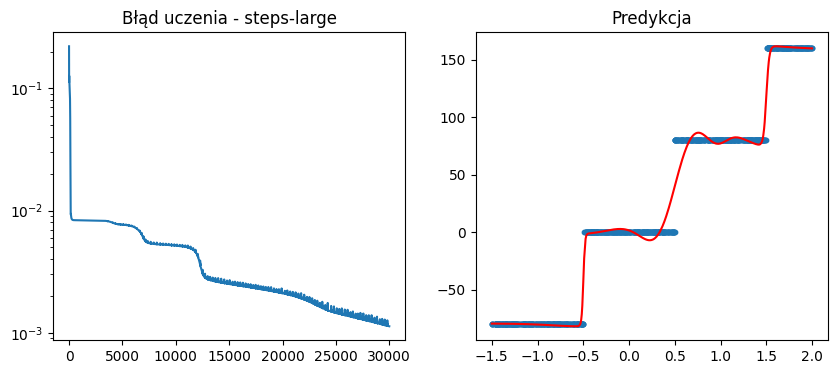

W_steps_large_5 = []
b_steps_large_5 = []
W_steps_large_5.append(np.array([[10.007721900939941, 17.774368286132812, -9.729544639587402, 10.668717384338379, 11.998416900634766]]))
b_steps_large_5.append(np.array([-8.010595321655273, -8.328145027160645, 7.574260234832764, -5.935822010040283, -3.720773696899414]))
W_steps_large_5.append(np.array([[7.10729455947876, -8.137930870056152, 43.023643493652344, -93.28809356689453, -1.8798022270202637], [3.1414060592651367, -0.22091376781463623, -4.400150775909424, -148.60177612304688, -0.6573372483253479], [-2.261892080307007, 6.730233669281006, -57.124427795410156, 25.8206844329834, -1.5181399583816528], [-2.032602548599243, -2.942356586456299, 1.61018705368042, -127.0177230834961, 5.801812648773193], [0.8480774760246277, 0.12763553857803345, -1.3255583047866821, -75.78650665283203, -0.44350576400756836]]))
b_steps_large_5.append(np.array([-1.2560553550720215, 0.7468873262405396, -5.151273250579834, 19.545284271240234, -0.41836658120155334]))
W

In [63]:

print("ZBIÓR SQUARE-SIMPLE")

model_sq_1 = uruchom("square-simple", [1, 5, 1], kroki=15000)
model_sq_2 = uruchom("square-simple", [1, 10, 1], kroki=15000)
model_sq_3 = uruchom("square-simple", [1, 5, 5, 1], kroki=20000)


print("\nZBIÓR STEPS-LARGE")

model_st_1 = uruchom("steps-large", [1, 5, 1], kroki=25000)
model_st_2 = uruchom("steps-large", [1, 10, 1], kroki=25000)
model_st_3 = uruchom("steps-large", [1, 5, 5, 1], kroki=30000)

własna implementacja

In [69]:
def wlasny_sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))

def wlasny_forward_pass(X, lista_W, lista_b, aktywacja=wlasny_sigmoid):
    A = X
    for i in range(len(lista_W)):
        W, b = lista_W[i], lista_b[i]
        Z = A @ W + b
        if i < len(lista_W) - 1:
            A = aktywacja(Z)
        else:
            A = Z
    return A

def pobierz_wagi(model):
    """Automatycznie kopiuje i konwertuje wagi z wyuczonego modelu PyTorch do Numpy"""
    lista_W, lista_b = [], []
    for modul in model:
        if isinstance(modul, nn.Linear):
            lista_W.append(modul.weight.data.cpu().numpy().T)
            lista_b.append(modul.bias.data.cpu().numpy())
    return lista_W, lista_b

print("--- WERYFIKACJA WŁASNEJ IMPLEMENTACJI (FORWARD PASS) ---")

#SQUARE-SIMPLE (Najlepsza architektura: [1, 5, 5, 1] czyli model_sq_3)
W_sq, b_sq = pobierz_wagi(model_sq_3)

x_train_sq, y_train_sq = wczytaj_csv("square-simple-training.csv")
x_test_sq, y_test_sq = wczytaj_csv("square-simple-test.csv")

x_min_sq, x_max_sq = x_train_sq.min(), x_train_sq.max()
y_min_sq, y_max_sq = y_train_sq.min(), y_train_sq.max()

# Normalizacja, forward pass i denormalizacja
x_test_n_sq = (x_test_sq - x_min_sq) / (x_max_sq - x_min_sq)
y_pred_n_sq = wlasny_forward_pass(x_test_n_sq, W_sq, b_sq)
y_pred_sq = y_pred_n_sq * (y_max_sq - y_min_sq) + y_min_sq

mse_sq = np.mean((y_test_sq - y_pred_sq) ** 2)
print(f"MSE square-simple (własna impl dla [1, 5, 5, 1]): {mse_sq:.4f}")


#STEPS-LARGE (Najlepsza architektura: [1, 5, 5, 1] czyli model_st_3)
W_st, b_st = pobierz_wagi(model_st_3)

# Wczytanie danych
x_train_st, y_train_st = wczytaj_csv("steps-large-training.csv")
x_test_st, y_test_st = wczytaj_csv("steps-large-test.csv")

# Dynamiczne wyznaczenie minimów i maksimów z danych treningowych
x_min_st, x_max_st = x_train_st.min(), x_train_st.max()
y_min_st, y_max_st = y_train_st.min(), y_train_st.max()

# Normalizacja, forward pass i denormalizacja
x_test_n_st = (x_test_st - x_min_st) / (x_max_st - x_min_st)
y_pred_n_st = wlasny_forward_pass(x_test_n_st, W_st, b_st)
y_pred_st = y_pred_n_st * (y_max_st - y_min_st) + y_min_st

mse_st = np.mean((y_test_st - y_pred_st) ** 2)
print(f"MSE steps-large   (własna impl dla [1, 5, 5, 1]): {mse_st:.4f}")

--- WERYFIKACJA WŁASNEJ IMPLEMENTACJI (FORWARD PASS) ---
MSE square-simple (własna impl dla [1, 5, 5, 1]): 0.5961
MSE steps-large   (własna impl dla [1, 5, 5, 1]): 56.4672


Wizualizacja predykcji dla własnego Forward Pass:


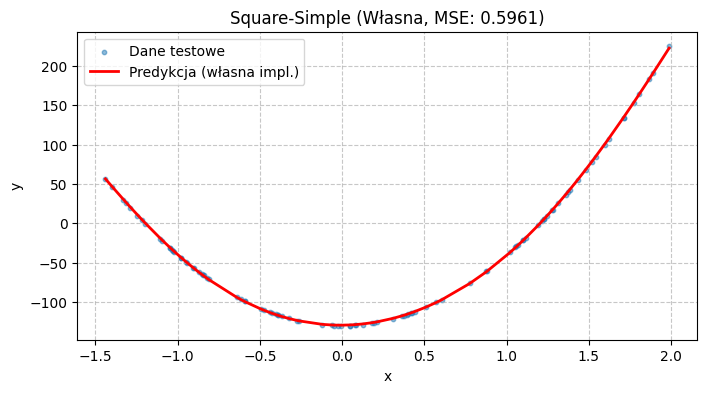

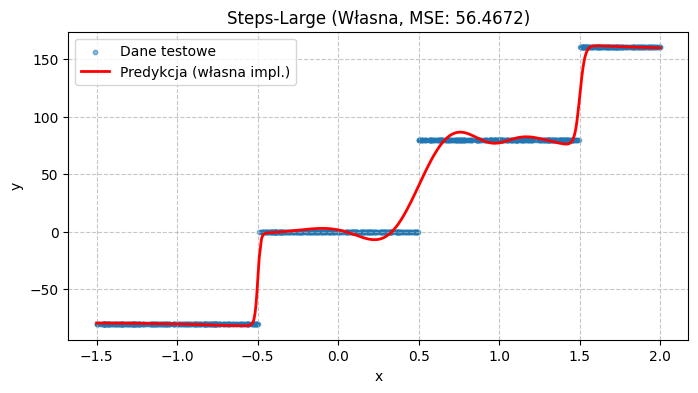

In [70]:
import matplotlib.pyplot as plt

def pokaz_wyniki_wlasne(x_test, y_test, y_pred, tytul):
    plt.figure(figsize=(8, 4))
    idx = np.argsort(x_test.flatten())
    plt.scatter(x_test, y_test, s=10, label='Dane testowe', alpha=0.5)
    plt.plot(x_test[idx], y_pred[idx], color='red', linewidth=2, label='Predykcja (własna impl.)')
    plt.title(tytul)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

print("Wizualizacja predykcji dla własnego Forward Pass:")
pokaz_wyniki_wlasne(x_test_sq, y_test_sq, y_pred_sq, f"Square-Simple (Własna, MSE: {mse_sq:.4f})")
pokaz_wyniki_wlasne(x_test_st, y_test_st, y_pred_st, f"Steps-Large (Własna, MSE: {mse_st:.4f})")